In [8]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings

In [12]:
df= pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [22]:
X= df[['Annual Income (k$)','Spending Score (1-100)']]
scaler= StandardScaler()
x_scaled= scaler.fit_transform(X)
print("completed data scaling")

completed data scaling


In [36]:
WCSS=[]
for i in range(1,11):
    Kmeans= KMeans(n_clusters=i, init="k-means++", random_state=42, n_init=10)
    Kmeans.fit(x_scaled)
    WCSS.append(Kmeans.inertia_)
warnings.filterwarnings('ignore')


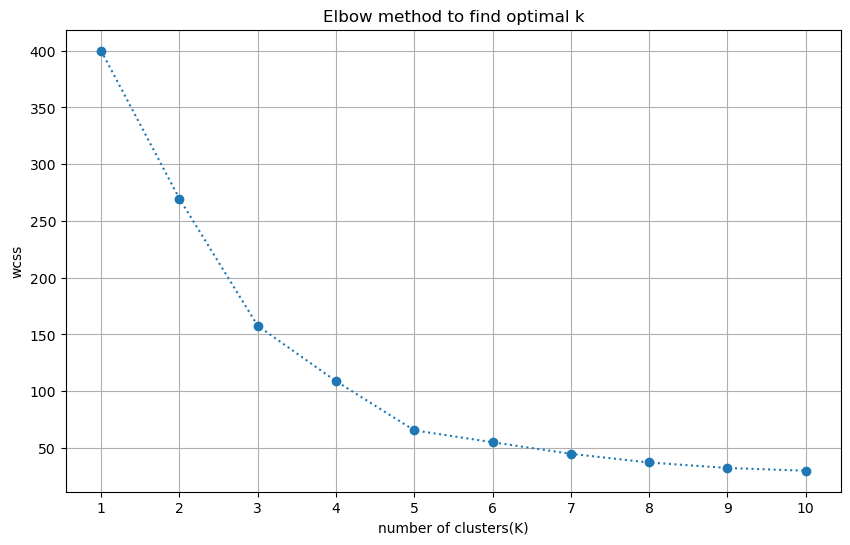

In [64]:
plt.figure(figsize=(10,6))
plt.plot(range(1,11), WCSS, marker='o', linestyle=':')
plt.title("Elbow method to find optimal k")
plt.xlabel("number of clusters(K)")
plt.ylabel("wcss")
plt.xticks(range(1,11))
plt.grid(True)
plt.show()

In [68]:
optimal_k=5
print(f"{optimal_k} is choosen as the optimal-k as per the graph")
print("now we will build final k-means model")

5 is choosen as the optimal-k as per the graph
now we will build final k-means model


In [74]:
final_kmeans_model= KMeans(n_clusters=optimal_k, init= "k-means++", random_state=42, n_init=10)
df['Cluster'] = final_kmeans_model.fit_predict(x_scaled)
print("clustering is completed and each customer got their seperate number")

clustering is completed and each customer got their seperate number


In [80]:
centeroids_scaled=final_kmeans_model.cluster_centers_

In [90]:
centeroids_original_scaled= scaler.inverse_transform(centeroids_scaled)
centeroids_df= pd.DataFrame(centeroids_original_scaled, columns=['Annual Income (k$)', 'Spending Score (1-100)'])
centeroids_df['Cluster'] = range(optimal_k)

In [100]:
print("\nEvery group's annual income and spending score")
print(df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())


Every group's annual income and spending score
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043



Groups ka graph pr plotting...

Customer groups's graph.
Har color ek alag customer group ko dikhata hai, aur red 'X' un groups ke centers hain.


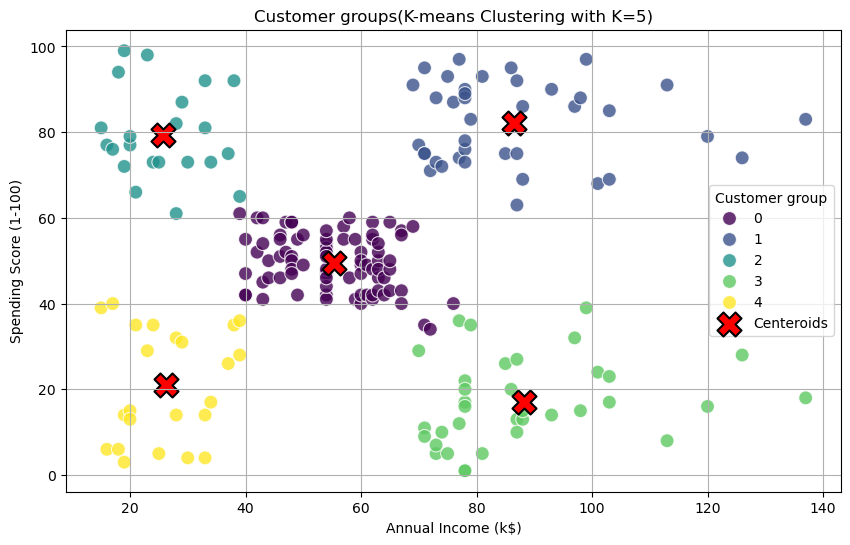

In [130]:
print("\nGroups ka graph pr plotting...")
print("\nCustomer groups's graph.")
print("Har color ek alag customer group ko dikhata hai, aur red 'X' un groups ke centers hain.")

plt.figure(figsize=(10,6))
sns.scatterplot(x="Annual Income (k$)", y="Spending Score (1-100)",hue= "Cluster",data= df, palette="viridis",s=100,alpha=0.8,edgecolor='w')
plt.scatter(centeroids_df['Annual Income (k$)'], centeroids_df['Spending Score (1-100)'], marker="X",s=300, color="Red", label="Centeroids",edgecolor="black", linewidth=1.5)
plt.title(f"Customer groups(K-means Clustering with K={optimal_k})")
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title="Customer group")
plt.grid(True)
plt.show()